In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
import black_litterman_recommender as blr
import importlib

importlib.reload(blr)

<module 'black_litterman_recommender' from '/home/neo_chavez/personal/Markowitz_Optimization/black_litterman_recommender.py'>

In [3]:
import utils as ut
import data_prep
import markowitz_analysis as ma
import markowitz_plots as mp

In [4]:
df = pd.read_csv('cleaned_ratings.csv', index_col=0)

In [5]:
stock_data_df, stock_data, stock_prices, returns_matrix = data_prep.load_sp500_data("sp500long.csv")

In [6]:
util = blr.stocktwits_to_sentiment_matrix(
    df,
    user_col = "user_id",
    asset_col = "symbol_list",
    sentiment_col = "sentiment",
    bullish_values = (1, "bullish", "Bullish", "BULLISH"),
    bearish_values = (-1,"bearish", "Bearish", "BEARISH"),
)

In [7]:
util = util[returns_matrix.columns.intersection(util.columns)]

In [8]:
U, V, _ = blr.als_explicit(util, 8, lam=0.1, max_iter=50, tol=1e-4, seed=42)

In [9]:
investor_id = 5
recs, scores = blr.recommend_from_als(util, U, V, investor_id, top_n=500)

In [10]:
scores = blr.investor_recommender_scores_als(
    M=util,
    U=U,
    V=V,
    investor_id=investor_id,
    exclude_observed=True,
)

In [11]:
returns_train = returns_matrix[returns_matrix.index < "2024-01-01"]
returns_train = returns_train[returns_train.index >= "2022-01-01"]
prior_mu = returns_train[util.iloc[:,recs].columns]
assets = pd.Index(util.iloc[:, recs].columns).astype(str)

R = returns_train.reindex(columns=assets)

# keep only assets with complete data for this window
R = R.dropna(axis=1, how="any")

assets = R.columns

prior_mu = R.mean().to_numpy().reshape(-1, 1)   # (n, 1)
sigma_prior = R.cov().to_numpy()                # (n, n)

tau=0.01
# P must also be built on these same assets, in this exact order

In [1]:
from sklearn.covariance import LedoitWolf
sigma_prior = LedoitWolf().fit(R).covariance_

NameError: name 'R' is not defined

In [13]:
P, Q, Omega, view_table = blr.build_relative_views_from_scores(
    scores=scores[assets],
    tickers=assets,
    sigma_prior=sigma_prior,
    tau=tau,
    n_views=100,
    view_return_scale=0.04 / 252,
    min_confidence = 0.35,
    max_confidence = 0.90,
)

In [14]:
posterior_mu, posterior_sigma = blr.black_litterman_posterior(
        prior_mu=prior_mu,
        sigma_prior=sigma_prior,
        P=P,
        Q=Q,
        Omega=Omega,
        tau=tau,
    )

In [15]:
N = len(assets)
min_vol_max_sharpe_bl, _, weights_bl = ut.min_vol_max_sharpe(
    posterior_mu,
    posterior_sigma,
    N,
    R,
    risk_free_rate=0.04 / 252,
)

In [16]:
# choose one portfolio weights vector
w_bl = weights_bl[1]   # [0] min-vol, [1] max-Sharpe

last_R_date = R.index.max()

# future slice from the full returns matrix
future_returns = returns_matrix.loc[returns_matrix.index > last_R_date]

# portfolio returns on dates after the last date in R
bl_ret_future = (
    future_returns.reindex(columns=w_bl.index) * w_bl
).sum(axis=1)

bl_ret_future.head()

Date
2024-01-02    0.004050
2024-01-03    0.004961
2024-01-04   -0.001070
2024-01-05    0.000300
2024-01-08    0.016758
dtype: float64

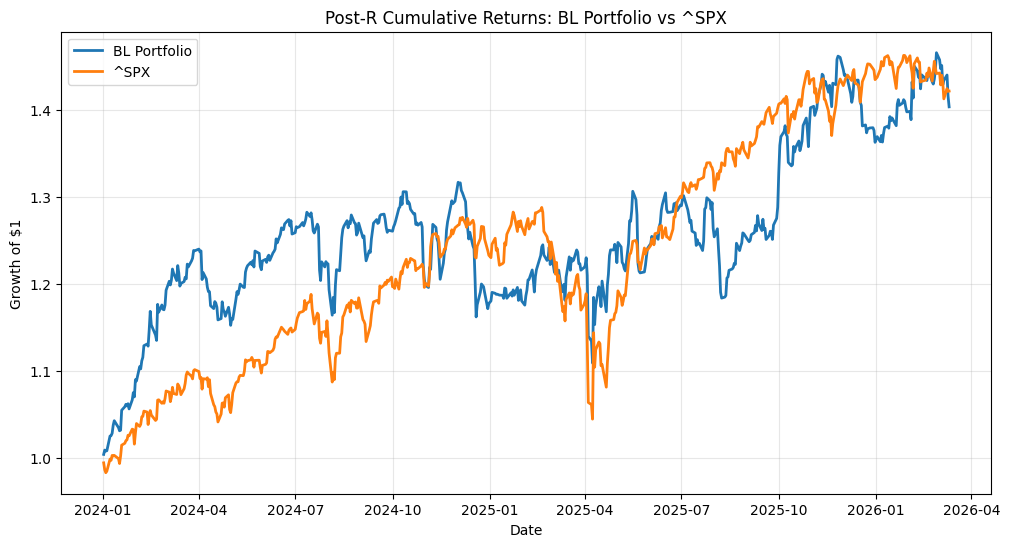

In [17]:
benchmark_ticker = "^SPX"   # or "^GSPC"

bench_ret_future = future_returns[benchmark_ticker]
if isinstance(bench_ret_future, pd.DataFrame):
    bench_ret_future = bench_ret_future.iloc[:, 0]

plot_df_future = pd.concat(
    [
        bl_ret_future.rename("BL Portfolio"),
        bench_ret_future.rename(benchmark_ticker),
    ],
    axis=1,
).dropna()

cum_df_future = (1 + plot_df_future).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cum_df_future.index, cum_df_future["BL Portfolio"], label="BL Portfolio", linewidth=2)
plt.plot(cum_df_future.index, cum_df_future[benchmark_ticker], label=benchmark_ticker, linewidth=2)
plt.title(f"Post-R Cumulative Returns: BL Portfolio vs {benchmark_ticker}")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [18]:
means = []
seeds = [42, 67, 69, 1337, 420]
for seed in seeds:
    util_train, util_test = blr.make_holdout(util, test_frac=0.2, min_pos=2, seed=seed)
    als_ndcg = blr.mean_ndcg_from_scores(
        M_train=util_train,
        M_test=util_test,
        U=U,
        V=V,
        k=10,
    )

    pop_ndcg = blr.mean_ndcg_from_popularity(
        M_train=util_train,
        M_test=util_test,
        k=10,
    )
    means.append((als_ndcg, pop_ndcg))
    print("ALS mean NDCG@10:", als_ndcg)
    print("Popularity mean NDCG@10:", pop_ndcg)
    print("Lift over popularity:", als_ndcg - pop_ndcg)

ALS mean NDCG@10: 0.1290154585615914
Popularity mean NDCG@10: 0.0007985643482433277
Lift over popularity: 0.1282168942133481
ALS mean NDCG@10: 0.12862196972768417
Popularity mean NDCG@10: 0.0008802338148246388
Lift over popularity: 0.12774173591285953
ALS mean NDCG@10: 0.12897048635803163
Popularity mean NDCG@10: 0.0007350584682578716
Lift over popularity: 0.12823542788977377
ALS mean NDCG@10: 0.12921266881499358
Popularity mean NDCG@10: 0.0006855733644881388
Lift over popularity: 0.12852709545050545
ALS mean NDCG@10: 0.12902991130444633
Popularity mean NDCG@10: 0.0007753179179787167
Lift over popularity: 0.1282545933864676


In [19]:
means_neighborhood = []
seeds = [42, 67, 69, 1337, 420]
for seed in seeds:
    util_train, util_test = blr.make_holdout(util, test_frac=0.2, min_pos=2, seed=seed)

    uu_ndcg = blr.mean_ndcg_from_user_user(M_train=util_train, M_test=util_test, k=10, top_k_neighbors=25)
    ii_ndcg = blr.mean_ndcg_from_item_item(M_train=util_train, M_test=util_test, k=10, top_k_neighbors=25)


    pop_ndcg = blr.mean_ndcg_from_popularity(
        M_train=util_train,
        M_test=util_test,
        k=10,
    )

    means_neighborhood.append((uu_ndcg, ii_ndcg, pop_ndcg))
    print("User-User mean NDCG@10:", uu_ndcg)
    print("Item-Item mean NDCG@10:", ii_ndcg)
    print("Popularity mean NDCG@10:", pop_ndcg)
    print("User-User lift over popularity:", uu_ndcg - pop_ndcg)
    print("Item-Item lift over popularity:", ii_ndcg - pop_ndcg)


User-User mean NDCG@10: 0.056928337189510674
Item-Item mean NDCG@10: 0.06319734583722018
Popularity mean NDCG@10: 0.0007985643482433277
User-User lift over popularity: 0.05612977284126735
Item-Item lift over popularity: 0.06239878148897686
User-User mean NDCG@10: 0.05604578650650579
Item-Item mean NDCG@10: 0.06641835490565436
Popularity mean NDCG@10: 0.0008802338148246388
User-User lift over popularity: 0.05516555269168115
Item-Item lift over popularity: 0.06553812109082972
User-User mean NDCG@10: 0.054984523677748004
Item-Item mean NDCG@10: 0.0630607178423173
Popularity mean NDCG@10: 0.0007350584682578716
User-User lift over popularity: 0.05424946520949013
Item-Item lift over popularity: 0.06232565937405943
User-User mean NDCG@10: 0.05680112899463596
Item-Item mean NDCG@10: 0.06213807587828855
Popularity mean NDCG@10: 0.0006855733644881388
User-User lift over popularity: 0.05611555563014783
Item-Item lift over popularity: 0.06145250251380041
User-User mean NDCG@10: 0.05635708333590921

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def compute_mean_recalls(seed, k=10, top_k_neighbors=25):
    util_train, util_test = blr.make_holdout(util, test_frac=0.2, min_pos=2, seed=seed)

    als_recall = blr.mean_recall_from_scores(
        M_train=util_train,
        M_test=util_test,
        U=U,
        V=V,
        k=k,
    )

    pop_recall = blr.mean_recall_from_popularity(
        M_train=util_train,
        M_test=util_test,
        k=k,
    )

    uu_recall = blr.mean_recall_from_user_user(
        M_train=util_train,
        M_test=util_test,
        k=k,
        top_k_neighbors=top_k_neighbors,
    )

    ii_recall = blr.mean_recall_from_item_item(
        M_train=util_train,
        M_test=util_test,
        k=k,
        top_k_neighbors=top_k_neighbors,
    )

    return {
        "als": als_recall,
        "popularity": pop_recall,
        "user_user": uu_recall,
        "item_item": ii_recall,
    }

seeds = [42]
results_by_seed = {}

with ThreadPoolExecutor(max_workers=6) as ex:
    futures = {ex.submit(compute_mean_recalls, seed): seed for seed in seeds}
    for fut in as_completed(futures):
        seed = futures[fut]
        results_by_seed[seed] = fut.result()

means_recall = []
for seed in seeds:
    r = results_by_seed[seed]
    means_recall.append((r["popularity"], r["user_user"], r["item_item"], r["als"]))

    print(f"Seed {seed}")
    print("Popularity mean Recall@10:", r["popularity"])
    print("User-User mean Recall@10:", r["user_user"]) 
    print("Item-Item mean Recall@10:", r["item_item"])
    print("ALS mean Recall@10:", r["als"])
    print("ALS lift over popularity:", r["als"] - r["popularity"])
    print("User-User lift over popularity:", r["user_user"] - r["popularity"])
    print("Item-Item lift over popularity:", r["item_item"] - r["popularity"])
    print("-" * 50)


Seed 42
Popularity mean Recall@10: 0.0018049623607307346
User-User mean Recall@10: 0.11706997788655728
Item-Item mean Recall@10: 0.13084608191492386
ALS mean Recall@10: 0.24568531210686895
ALS lift over popularity: 0.2438803497461382
User-User lift over popularity: 0.11526501552582655
Item-Item lift over popularity: 0.12904111955419312
--------------------------------------------------


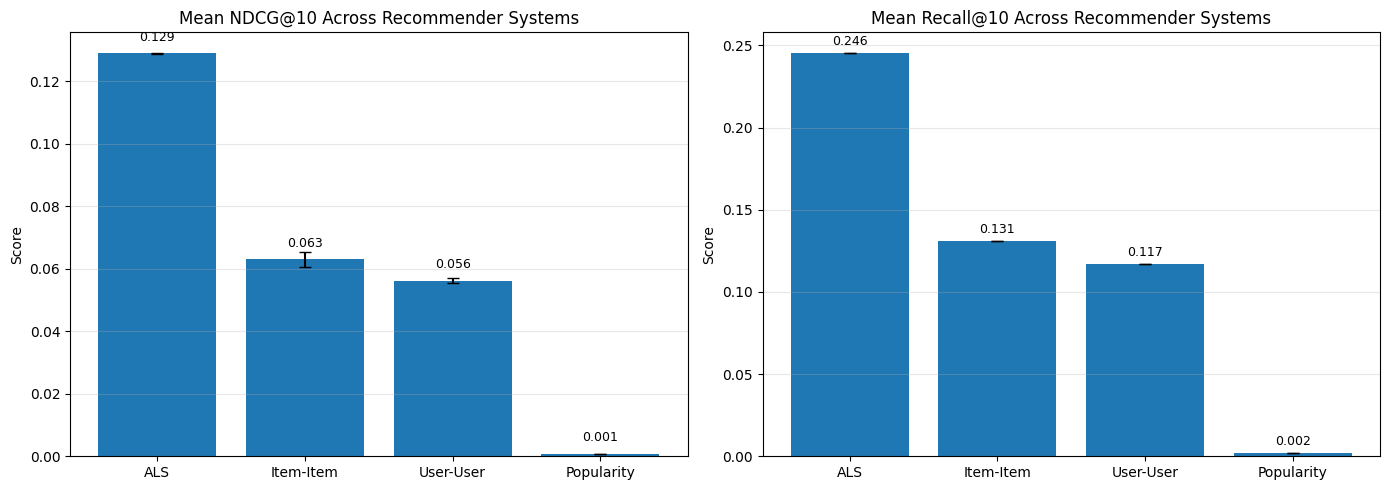

,Recommender,Mean NDCG@10,Std NDCG@10,Mean Recall@10,Std Recall@10
3,ALS,0.128970,0.000215,0.245685,0.0
2,Item-Item,0.062989,0.002275,0.130846,0.0
1,User-User,0.056223,0.000777,0.117070,0.0
0,Popularity,0.000775,0.000073,0.001805,0.0


In [ ]:
ndcg_scores = {
    "Popularity": [x[1] for x in means],
    "User-User": [x[0] for x in means_neighborhood],
    "Item-Item": [x[1] for x in means_neighborhood],
    "ALS": [x[0] for x in means],
}

recall_scores = {
    "Popularity": [x[0] for x in means_recall],
    "User-User": [x[1] for x in means_recall],
    "Item-Item": [x[2] for x in means_recall],
    "ALS": [x[3] for x in means_recall],
}

recommenders = ["Popularity", "User-User", "Item-Item", "ALS"]

summary = pd.DataFrame({
    "Recommender": recommenders,
    "Mean NDCG@10": [pd.Series(ndcg_scores[r]).mean() for r in recommenders],
    "Std NDCG@10": [pd.Series(ndcg_scores[r]).std(ddof=1) if len(ndcg_scores[r]) > 1 else 0.0 for r in recommenders],
    "Mean Recall@10": [pd.Series(recall_scores[r]).mean() for r in recommenders],
    "Std Recall@10": [pd.Series(recall_scores[r]).std(ddof=1) if len(recall_scores[r]) > 1 else 0.0 for r in recommenders],
}).sort_values("Mean NDCG@10", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean NDCG
axes[0].bar(
    summary["Recommender"],
    summary["Mean NDCG@10"],
    yerr=summary["Std NDCG@10"],
    capsize=4,
)
axes[0].set_title("Mean NDCG@10 Across Recommender Systems")
axes[0].set_ylabel("Score")
axes[0].grid(axis="y", alpha=0.3)

for i, v in enumerate(summary["Mean NDCG@10"]):
    axes[0].text(i, v + 0.003, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

# Mean Recall
axes[1].bar(
    summary["Recommender"],
    summary["Mean Recall@10"],
    yerr=summary["Std Recall@10"],
    capsize=4,
)
axes[1].set_title("Mean Recall@10 Across Recommender Systems")
axes[1].set_ylabel("Score")
axes[1].grid(axis="y", alpha=0.3)

for i, v in enumerate(summary["Mean Recall@10"]):
    axes[1].text(i, v + 0.003, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

summary

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def compute_mean_coverages(seed, k=10, top_k_neighbors=25):
    util_train, util_test = blr.make_holdout(util, test_frac=0.2, min_pos=2, seed=seed)

    als_coverage = blr.mean_coverage_from_scores(
        M_train=util_train,
        U=U,
        V=V,
        k=k,
    )

    pop_coverage = blr.mean_coverage_from_popularity(
        M_train=util_train,
        k=k,
    )

    uu_coverage = blr.mean_coverage_from_user_user(
        M_train=util_train,
        k=k,
        top_k_neighbors=top_k_neighbors,
    )

    ii_coverage = blr.mean_coverage_from_item_item(
        M_train=util_train,
        k=k,
        top_k_neighbors=top_k_neighbors,
    )

    return {
        "als": als_coverage,
        "popularity": pop_coverage,
        "user_user": uu_coverage,
        "item_item": ii_coverage,
    }

seeds = [42]
results_by_seed = {}

with ThreadPoolExecutor(max_workers=6) as ex:
    futures = {ex.submit(compute_mean_coverages, seed): seed for seed in seeds}
    for fut in as_completed(futures):
        seed = futures[fut]
        results_by_seed[seed] = fut.result()

means_coverage = []
for seed in seeds:
    r = results_by_seed[seed]
    means_coverage.append((r["popularity"], r["user_user"], r["item_item"], r["als"]))

    print(f"Seed {seed}")
    print("Popularity mean Coverage@10:", r["popularity"])
    print("User-User mean Coverage@10:", r["user_user"])
    print("Item-Item mean Coverage@10:", r["item_item"])
    print("ALS mean Coverage@10:", r["als"])
    print("ALS lift over popularity:", r["als"] - r["popularity"])
    print("User-User lift over popularity:", r["user_user"] - r["popularity"])
    print("Item-Item lift over popularity:", r["item_item"] - r["popularity"])
    print("-" * 50)


In [ ]:
coverage_scores = {
    "Popularity": [x[0] for x in means_coverage],
    "User-User": [x[1] for x in means_coverage],
    "Item-Item": [x[2] for x in means_coverage],
    "ALS": [x[3] for x in means_coverage],
}

recommenders = ["Popularity", "User-User", "Item-Item", "ALS"]

summary_coverage = pd.DataFrame({
    "Recommender": recommenders,
    "Mean Coverage@10": [pd.Series(coverage_scores[r]).mean() for r in recommenders],
    "Std Coverage@10": [pd.Series(coverage_scores[r]).std(ddof=1) if len(coverage_scores[r]) > 1 else 0.0 for r in recommenders],
}).sort_values("Mean Coverage@10", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(
    summary_coverage["Recommender"],
    summary_coverage["Mean Coverage@10"],
    yerr=summary_coverage["Std Coverage@10"],
    capsize=4,
)
plt.title("Mean Coverage@10 Across Recommender Systems")
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(summary_coverage["Mean Coverage@10"]):
    plt.text(i, v + 0.003, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

summary_coverage


In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def compute_mean_diversities(seed, k=10, top_k_neighbors=25):
    util_train, util_test = blr.make_holdout(util, test_frac=0.2, min_pos=2, seed=seed)

    als_diversity = blr.mean_diversity_from_scores(
        M_train=util_train,
        U=U,
        V=V,
        k=k,
    )

    pop_diversity = blr.mean_diversity_from_popularity(
        M_train=util_train,
        k=k,
    )

    uu_diversity = blr.mean_diversity_from_user_user(
        M_train=util_train,
        k=k,
        top_k_neighbors=top_k_neighbors,
    )

    ii_diversity = blr.mean_diversity_from_item_item(
        M_train=util_train,
        k=k,
        top_k_neighbors=top_k_neighbors,
    )

    return {
        "als": als_diversity,
        "popularity": pop_diversity,
        "user_user": uu_diversity,
        "item_item": ii_diversity,
    }

seeds = [42]
results_by_seed = {}

with ThreadPoolExecutor(max_workers=6) as ex:
    futures = {ex.submit(compute_mean_diversities, seed): seed for seed in seeds}
    for fut in as_completed(futures):
        seed = futures[fut]
        results_by_seed[seed] = fut.result()

means_diversity = []
for seed in seeds:
    r = results_by_seed[seed]
    means_diversity.append((r["popularity"], r["user_user"], r["item_item"], r["als"]))

    print(f"Seed {seed}")
    print("Popularity mean Diversity@10:", r["popularity"])
    print("User-User mean Diversity@10:", r["user_user"])
    print("Item-Item mean Diversity@10:", r["item_item"])
    print("ALS mean Diversity@10:", r["als"])
    print("ALS lift over popularity:", r["als"] - r["popularity"])
    print("User-User lift over popularity:", r["user_user"] - r["popularity"])
    print("Item-Item lift over popularity:", r["item_item"] - r["popularity"])
    print("-" * 50)


In [ ]:
diversity_scores = {
    "Popularity": [x[0] for x in means_diversity],
    "User-User": [x[1] for x in means_diversity],
    "Item-Item": [x[2] for x in means_diversity],
    "ALS": [x[3] for x in means_diversity],
}

recommenders = ["Popularity", "User-User", "Item-Item", "ALS"]

summary_diversity = pd.DataFrame({
    "Recommender": recommenders,
    "Mean Diversity@10": [pd.Series(diversity_scores[r]).mean() for r in recommenders],
    "Std Diversity@10": [pd.Series(diversity_scores[r]).std(ddof=1) if len(diversity_scores[r]) > 1 else 0.0 for r in recommenders],
}).sort_values("Mean Diversity@10", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(
    summary_diversity["Recommender"],
    summary_diversity["Mean Diversity@10"],
    yerr=summary_diversity["Std Diversity@10"],
    capsize=4,
)
plt.title("Mean Diversity@10 Across Recommender Systems")
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(summary_diversity["Mean Diversity@10"]):
    plt.text(i, v + 0.003, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

summary_diversity
